In [ ]:
# Setup: utilities for analysis
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8')

# Reuse helpers from src.utils
from src.utils.analysis import tsne_scatter_plot as tsne_scatter, predict_all


In [2]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))
import torch
import src
import matplotlib.pyplot as plt
from src.utils.utils import set_seed
import src.data.catalog as catalog
import src.catalogs as catalogs
import matplotlib.pyplot as plt
import numpy as np 
set_seed(0) 
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [3]:
from src.models.builders import ModelBuilder
from src.train.config_setup import load_args_from_checkpoint,load_model_from_checkpoint
checkpoint_dir = Path("../checkpoints/clf_mixer_attnpl_t_20260125-133053") 
checkpoint_path = checkpoint_dir / "best_model_1.pth"
check_point = torch.load(checkpoint_path,weights_only=False)
args = load_args_from_checkpoint(None, check_point)
model_builder = ModelBuilder.by_name(args.model.lower())()
model = model_builder(args, device)
model,_,_ = load_model_from_checkpoint(model, check_point)
model = torch.compile(model)
model.eval() 

Initializing MixerAdapter with stats: {'tau_unfiltered': 0.15339908988298961, 'tau_q025': 0.08114294020924717, 'tau_q05': 0.5134664350189269, 'tau_mean': 1.3070542199341526, 'tau_max': 25.18216435192153, 'tau_min': 0.0, 'time_max': 18770.72654999979, 'time_mean': 10030.9430649837, 'mag_completeness': 3.0, 'mag_mean': 3.456916005014626, 'mag_max': 8.0, 'mag_min': 3.0, 'b_value': 0.856738547623331, 'b_std': 0.0071499224812533796, 'b_n': 14358}
using extractor: attn_time_biased_mh time_bias_type: log extractor_config: {}
load_specific_parts: None
Checkpoint loaded: _IncompatibleKeys(missing_keys=['base_model.encoder.input_proj.weight', 'base_model.encoder.input_proj.bias'], unexpected_keys=['base_model.encoder.input_linear.weight', 'base_model.encoder.input_linear.bias'])
hyperparameters: {'resume_path': './checkpoints/mixer_tpp_20260125-132634/last_model_1.pth', 'load_specific_parts': ['encoder'], 'model': 'clf_mixer_attnpl_t', 'use_ema': False, 'batch_size': 64, 'accumulation_steps': 1,

OptimizedModule(
  (_orig_mod): TaskModel(
    (base_model): MixerModelWrapper(
      (encoder): MixerModel(
        (input_proj): Linear(in_features=1, out_features=64, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (layers): ModuleList(
          (0): Block(
            (norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
            (mixer): Mamba2Rotary(
              (in_proj): Linear(in_features=64, out_features=514, bias=False)
              (act): SiLU()
              (norm): RMSNorm()
              (out_proj): Linear(in_features=128, out_features=64, bias=False)
              (rotary_emb): RotaryEmbeddingTime()
            )
            (dropout): Dropout(p=0.1, inplace=False)
            (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
            (mlp): GatedMLP(
              (fc1): Linear(in_features=64, out_features=256, bias=False)
              (fc2): Linear(in_features=128, out_features=64, bias=False)
            )
          )

In [4]:
model.eval()
model.extractor.g

Parameter containing:
tensor([0.0552, 0.0107, 0.0006, 0.0123], device='cuda:0', requires_grad=True)

In [5]:
from src.data.preparation import prepare_data
base_dir = f"../data/{args.dataset}"
df, train_loader, val_loader, test_loader, catalog_ds = prepare_data(base_dir=base_dir, args=args,)

CSV files found: ['Chuandian2021.csv']
Catalog statistics: {'tau_unfiltered': 0.15339908988298961, 'tau_q025': 0.08114294020924717, 'tau_q05': 0.5134664350189269, 'tau_mean': 1.3070542199341526, 'tau_max': 25.18216435192153, 'tau_min': 0.0, 'time_max': 18770.72654999979, 'time_mean': 10030.9430649837, 'mag_completeness': 3.0, 'mag_mean': 3.456916005014626, 'mag_max': 8.0, 'mag_min': 3.0, 'b_value': 0.856738547623331, 'b_std': 0.0071499224812533796, 'b_n': 14358}
stas {'tau_unfiltered': 0.15339908988298961, 'tau_q025': 0.08114294020924717, 'tau_q05': 0.5134664350189269, 'tau_mean': 1.3070542199341526, 'tau_max': 25.18216435192153, 'tau_min': 0.0, 'time_max': 18770.72654999979, 'time_mean': 10030.9430649837, 'mag_completeness': 3.0, 'mag_mean': 3.456916005014626, 'mag_max': 8.0, 'mag_min': 3.0, 'b_value': 0.856738547623331, 'b_std': 0.0071499224812533796, 'b_n': 14358}
[✔] Loading cached data from: ../data/ChuanDian/processed/classifier/classifier_Mc_3_Mf_4.5_Tfore_30_Twindow_180_context

In [6]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu") 

In [7]:
import src.data.event_loader as loader
args.batch_size =32
data_loader = loader.get_dataloader(catalog_ds, batch_size=args.batch_size, shuffle=False, task_type=args.task_type)

Positive samples: 836, Negative samples: 594
Total samples: 1430, Positive ratio: 0.58, Negative ratio: 0.42


In [8]:
for x, y in val_loader:
    x, y = x.to(device), y.to(device)
    break

In [9]:
model.base_model.encoder.layers[2]


Block(
  (norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  (mixer): Mamba2Rotary(
    (in_proj): Linear(in_features=64, out_features=514, bias=False)
    (act): SiLU()
    (norm): RMSNorm()
    (out_proj): Linear(in_features=128, out_features=64, bias=False)
    (rotary_emb): RotaryEmbeddingTime()
  )
  (dropout): Dropout(p=0.1, inplace=False)
  (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  (mlp): GatedMLP(
    (fc1): Linear(in_features=64, out_features=256, bias=False)
    (fc2): Linear(in_features=128, out_features=64, bias=False)
  )
)

In [10]:
# model.base_model.input_adapter(x)['features'][0,:,0]

In [11]:
model.eval()
model.extractor.t_mlp.to(device)
x_lin = torch.linspace(0, 1, 100).unsqueeze(1)  
x_lin = x_lin.to(device)  
gamma, beta = model.extractor.t_mlp(x_lin).chunk(2, dim=-1)  

In [ ]:
# Use the reusable predict_all from src.utils.analysis
from src.utils.analysis import predict_all

In [13]:
from src.utils.metrics import classification_metrics, log_metrics, plot_and_save_roc_curve, plot_classification_distribution
y_pred_val, y_val, X_val = predict_all(model,val_loader, device, return_X=True)
y_pred_train , y_train, X_train = predict_all(model, train_loader, device, return_X=True)
# Test features/labels
y_pred_test, y_test, X_test = predict_all(model, test_loader, device, return_X=True)

/root/miniconda3/lib/python3.12/site-packages/torch/_inductor/compile_fx.py:167: UserWarning: TensorFloat32 tensor cores for float32 matrix multiplication available but not enabled. Consider setting `torch.set_float32_matmul_precision('high')` for better performance.
  warnings.warn(


In [14]:
# Helper: run classification metrics & t-SNE by split (English messages)
def run_metrics_and_tsne_for_splits(splits=("val",), do_tsne=True):
    split_data = {
        "train": {"X": X_train, "y": y_train, "y_pred": y_pred_train},
        "val":   {"X": X_val,   "y": y_val,   "y_pred": y_pred_val},
        "test":  {"X": X_test,  "y": y_test,  "y_pred": y_pred_test},
    }

    for split in splits:
        if split not in split_data:
            print(f"[Skip] Unknown split: {split}")
            continue

        d = split_data[split]
        y = d["y"]
        y_pred = d["y_pred"]

        print(f"=== {split.upper()}: classification_metrics ===")
        try:
            print(classification_metrics(y, y_pred))
        except Exception as e:
            print(f"[Warn] classification_metrics({split}) failed: {e}")

        if do_tsne:
            try:
                X = d["X"].astype(float)
                _ , _ = tsne_scatter(
                    X,
                    y_true=y,
                    y_score=y_pred,
                    title_left=f"t-SNE colored by true label ({split})",
                    title_right=f"t-SNE colored by model score ({split})",
                )
            except Exception as e:
                print(f"[Warn] t-SNE({split}) failed: {e}")


=== TRAIN: classification_metrics ===
{'precision': 0.6919275123558485, 'recall': 0.7241379310344828, 'f1': 0.7076663858466723, 'auc': 0.7630961115187087, 'pr_auc': 0.8142386656958244, 'fpr': 0.33156028368794327, 'tpr': 0.7241379310344828, 'R': 0.3925776473465395, 'conf': 1.0, 'threshold': 0.36370542645454407}


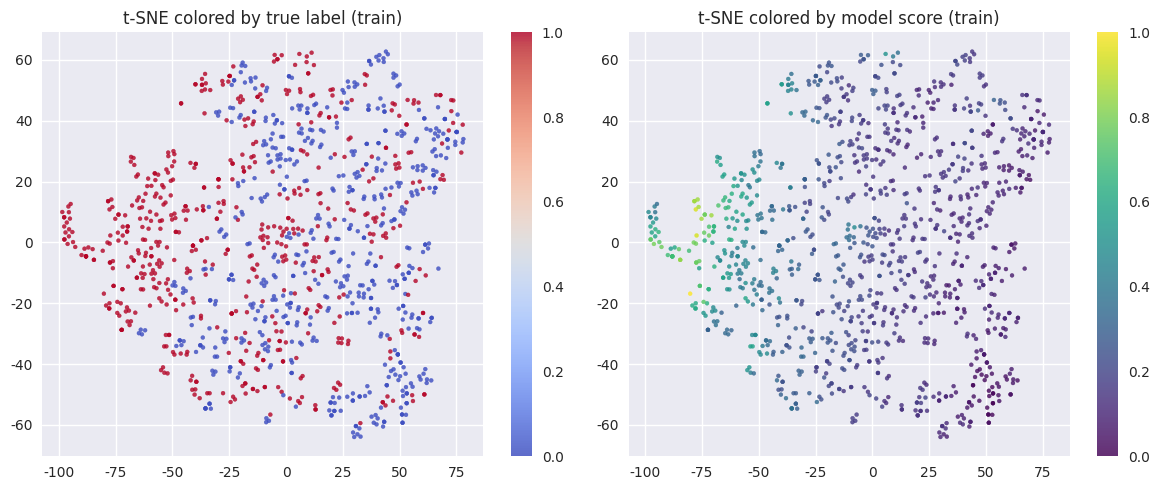

=== VAL: classification_metrics ===
{'precision': 0.6756756756756757, 'recall': 0.9036144578313253, 'f1': 0.7731958762886598, 'auc': 0.7046184738955823, 'pr_auc': 0.7665295836648645, 'fpr': 0.6, 'tpr': 0.9036144578313253, 'R': 0.30361445783132535, 'conf': 0.9859123160144256, 'threshold': 0.33206862211227417}


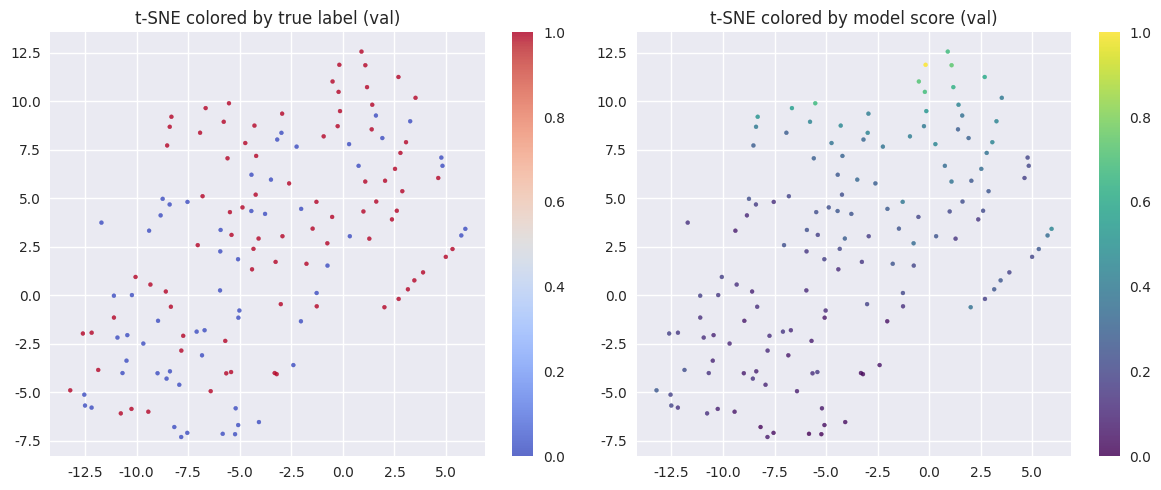

=== TEST: classification_metrics ===
{'precision': 0.5131578947368421, 'recall': 0.8297872340425532, 'f1': 0.6341463414634146, 'auc': 0.8138297872340425, 'pr_auc': 0.7255233770593689, 'fpr': 0.3854166666666667, 'tpr': 0.8297872340425532, 'R': 0.4443705673758865, 'conf': 0.9999999999996156, 'threshold': 0.3370385468006134}


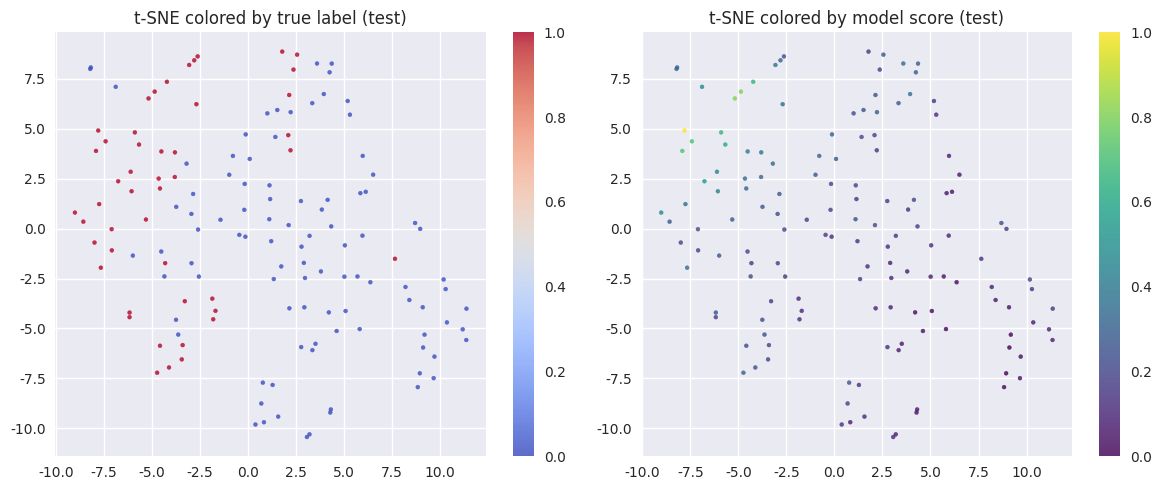

In [15]:
selected_splits = ["train", "val", "test"]
run_metrics_and_tsne_for_splits(selected_splits, do_tsne=True)


In [16]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score

# Train RF on pooled features from original training set
rf = RandomForestClassifier(n_estimators=200, random_state=0, n_jobs=-1)
rf.fit(X_train, y_train)

# Predict on pooled features from original test set
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

# Report metrics for RF predictions on test set
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf, digits=4))
print("ROC AUC:", roc_auc_score(y_test, y_proba_rf))

Accuracy: 0.6993006993006993
              precision    recall  f1-score   support

         0.0     0.8533    0.6667    0.7485        96
         1.0     0.5294    0.7660    0.6261        47

    accuracy                         0.6993       143
   macro avg     0.6914    0.7163    0.6873       143
weighted avg     0.7469    0.6993    0.7083       143

ROC AUC: 0.7965425531914894


In [17]:
# Normalize RF probabilities for optional plotting/comparison
y_proba_rf_nl = (y_proba_rf - y_proba_rf.min()) / (y_proba_rf.max() - y_proba_rf.min() + 1e-8)

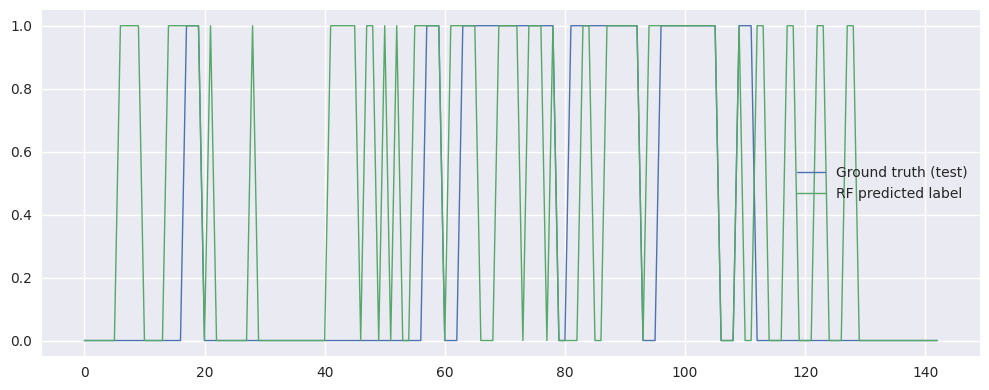

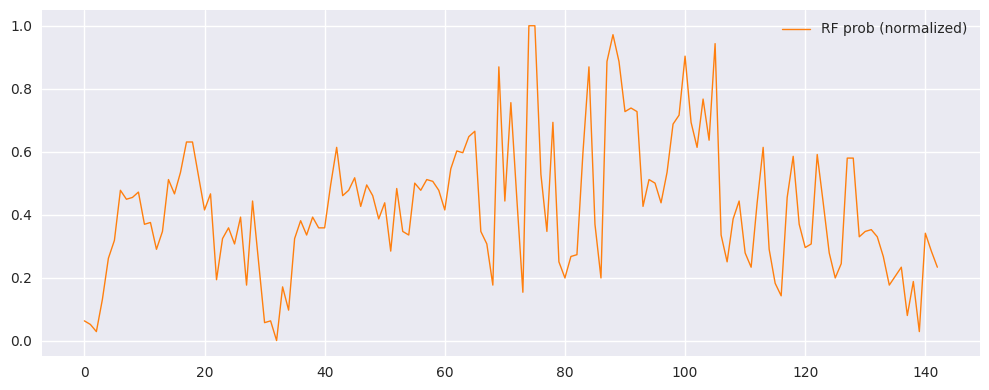

In [18]:
# Visualize ground truth vs RF predicted labels/probabilities on original test set
plt.figure(figsize=(10, 4))
plt.plot(y_test, label="Ground truth (test)", lw=1)
plt.plot(y_pred_rf, label="RF predicted label", lw=1)
plt.legend()
plt.tight_layout()
plt.show()

# Optional: visualize normalized RF probabilities
plt.figure(figsize=(10, 4))
plt.plot(y_proba_rf_nl, label="RF prob (normalized)", color="tab:orange", lw=1)
plt.legend()
plt.tight_layout()
plt.show()

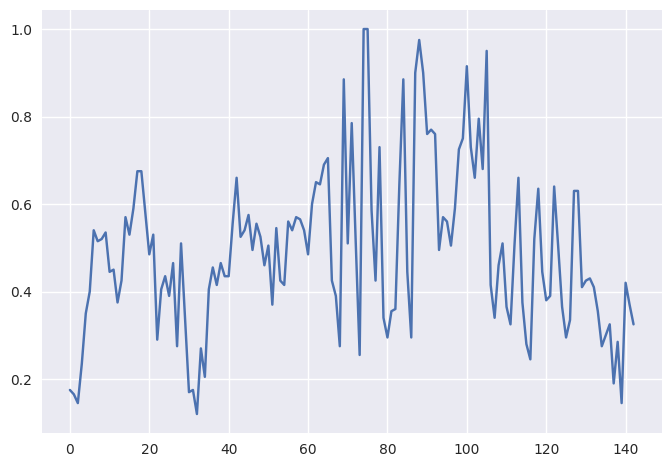

In [19]:
# Quick glance at RF raw probabilities
plt.plot(y_proba_rf)


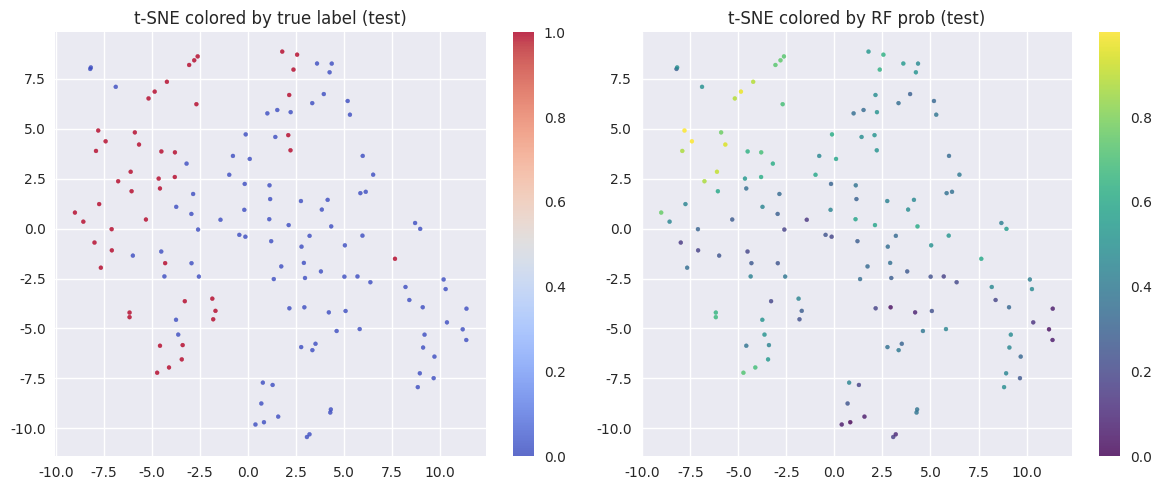

In [20]:
# t-SNE on test features colored by RF probability
# Ensure X_test, y_test, y_proba_rf_nl already computed.
_ , _ = tsne_scatter(
    X_test,
    y_true=y_test,
    y_score=y_proba_rf,
    title_left="t-SNE colored by true label (test)",
    title_right="t-SNE colored by RF prob (test)"
)


In [ ]:
# Import reusable Integrated Gradients and plotting helpers
from src.utils.interpretability import integrated_gradients_token_importance, plot_token_importance

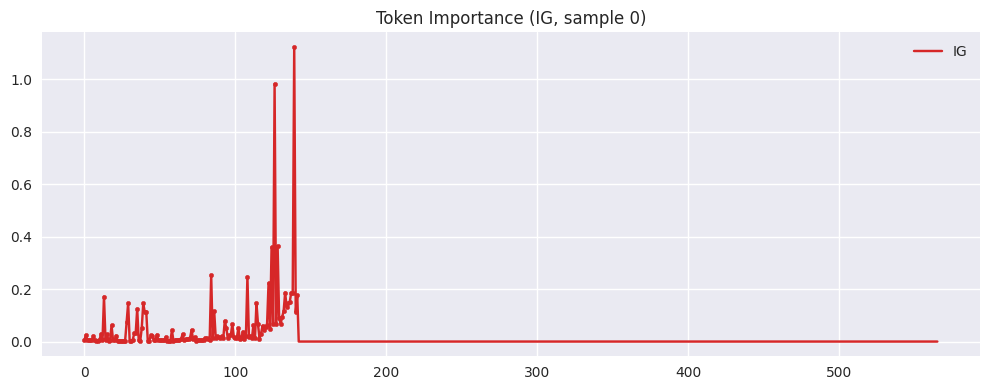

In [23]:
# Example: compute IG token importance and visualize for one sample
# Assumptions:
# - `model` and a batch `x: [B, L, D]` are available
# - `sample_idx` selects which sample to visualize

# Validate prerequisites
try:
    _ = model
    _ = x
except NameError:
    raise RuntimeError("Please define `model` and `x` earlier in the notebook.")

# Compute IG token importance
token_scores_ig = integrated_gradients_token_importance(model=model, x=x, baseline=None, n_steps=40)

# Select a sample for plotting
if 'sample_idx' not in globals():
    sample_idx = 0

# Optional: valid token mask (non-zero features)
valid_mask = (x.abs().sum(dim=-1) > 0)

# Visualize
plot_token_importance(scores=token_scores_ig, sample_idx=sample_idx, label='IG', mask=valid_mask, color='tab:red')